In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# graph display as correct manner
%matplotlib inline

print()

In [2]:
#add file
df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn_suraj singh g40aiml.csv')
#data size
print(f"data size:{df.shape}")
print(f"row:{df.shape[0]}")
print(f"columns:{df.shape[1]}\n")
df.head()

data size:(7043, 21)
row:7043
columns:21



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
if 'customerID' in df.columns:
  df = df.drop(columns=['customerID'])
  #column removed
  print("customerID")
#tatal charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
#missing values
print("each column missing value:")
print(df.isnull().sum())
#total charg in missing value
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)
print("correct missing value")

customerID
each column missing value:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
correct missing value


In [5]:
#duplicate row
duplicates = df.duplicated().sum()
print(f"all duplicate row:{duplicates}")
if duplicates > 0:
  df = df.drop_duplicates()
  print("removed duplicate rows")

all duplicate row:22
removed duplicate rows


In [16]:
df.to_csv('Cleaned_Customer_Churn_Dataset_Suraj_singh_G40_AIML.csv')
print("clean data saved")

clean data saved


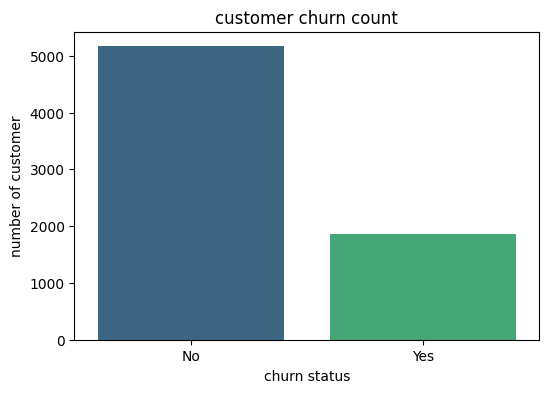

In [7]:
# churn count plot
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Churn',palette='viridis')
plt.title('customer churn count')
plt.xlabel('churn status')
plt.ylabel('number of customer')
plt.show()

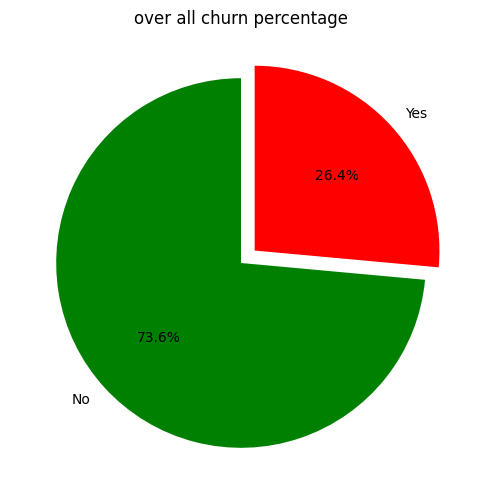

In [8]:
#pie chart , churn percentage
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot.pie(autopct ='%1.1f%%',colors=['green','red'],startangle=90,explode=(0,0.1))
plt.title("over all churn percentage")
plt.ylabel('')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

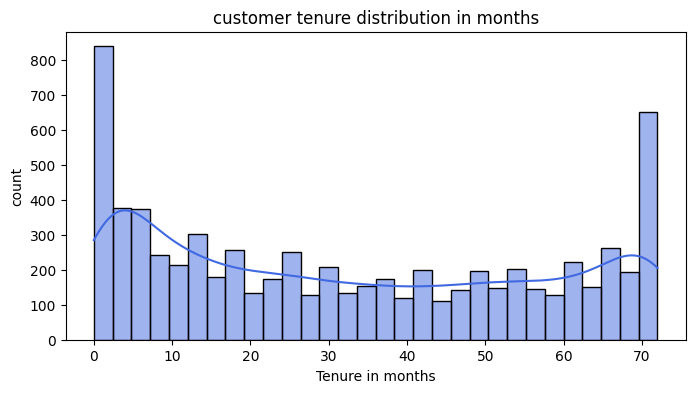

In [9]:
# histogram ofb tenure
plt.figure(figsize=(8,4))
sns.histplot(data=df,x='tenure',kde=True, bins=30,color='royalblue')
plt.title('customer tenure distribution in months')
plt.xlabel('Tenure in months')
plt.ylabel('count')
plt.show

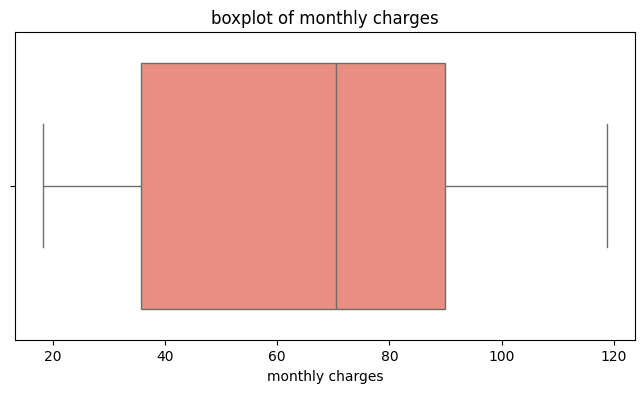

In [10]:
# Outlier detection Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data = df,x='MonthlyCharges',color='salmon')
plt.title('boxplot of monthly charges')
plt.xlabel('monthly charges')
plt.show()

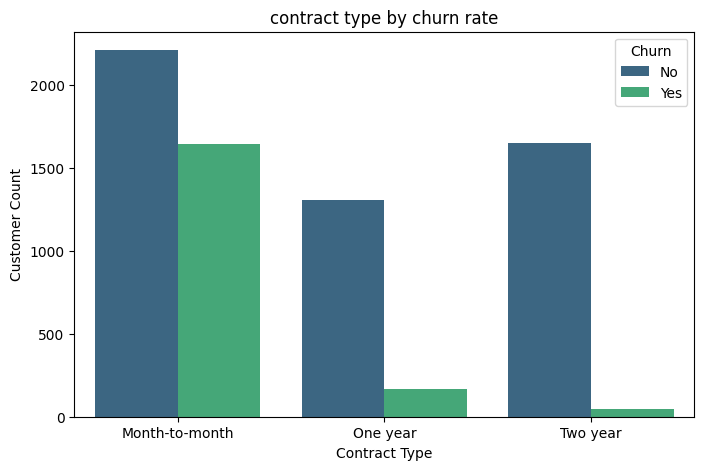

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
#contract type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data = df, x='Contract', hue='Churn', palette='viridis')
plt.title('contract type by churn rate')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.show()

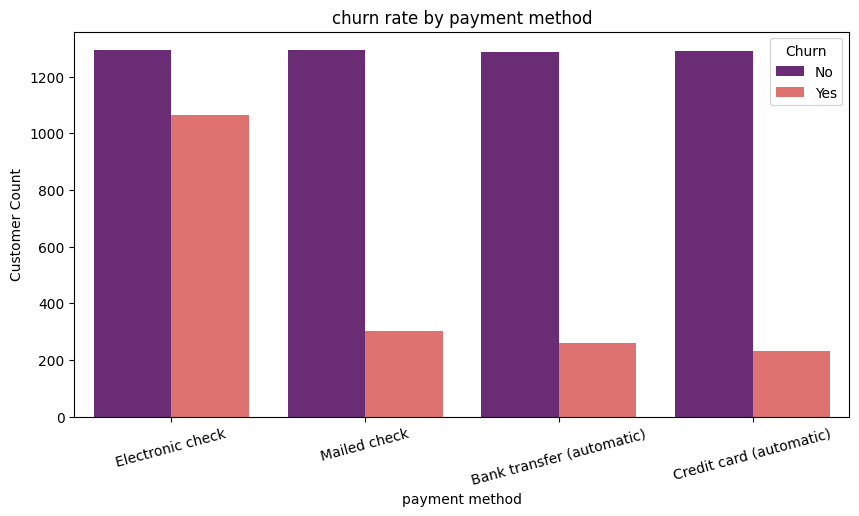

In [12]:
#payment method
plt.figure(figsize=(10,5))
sns.countplot(data = df, x='PaymentMethod', hue='Churn', palette='magma')
plt.xticks(rotation=15)
plt.title('churn rate by payment method')
plt.xlabel('payment method')
plt.ylabel('Customer Count')
plt.show()

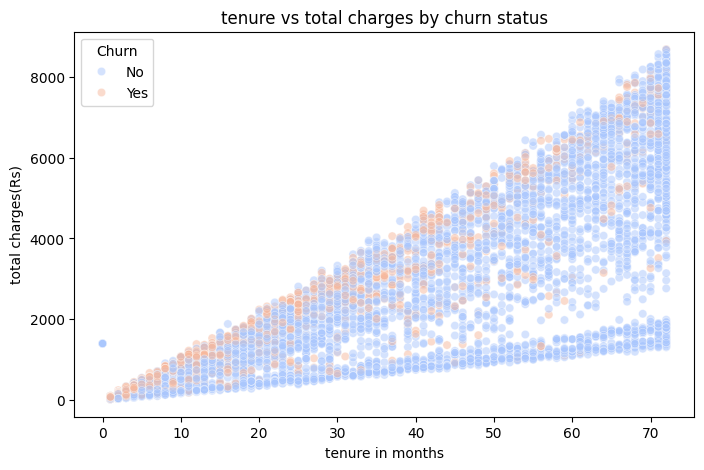

In [13]:
# scatter plot (tenure vs total charges)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='tenure',y='TotalCharges',hue='Churn',alpha=0.5,palette='coolwarm')
plt.title('tenure vs total charges by churn status')
plt.xlabel('tenure in months')
plt.ylabel('total charges(Rs)')
plt.show()


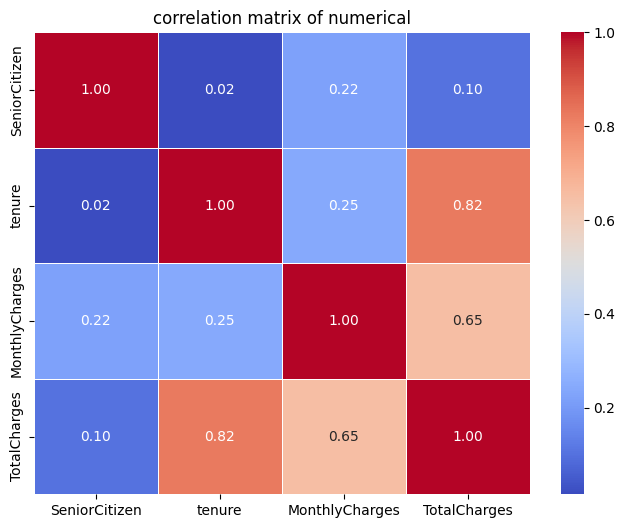

In [14]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm', fmt='.2f', linewidth = 0.5)
plt.title('correlation matrix of numerical')
plt.show()

In [15]:
print("numerical features discription")
print(df.describe())
# categorical data
print("\n categorical data")
print(df.describe(include=['O']))

numerical features discription
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7021.000000  7021.000000     7021.000000   7021.000000
mean        0.162512    32.469449       64.851894   2288.954490
std         0.368947    24.534965       30.069001   2265.319449
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.750000    411.150000
50%         0.000000    29.000000       70.400000   1400.550000
75%         0.000000    55.000000       89.900000   3801.700000
max         1.000000    72.000000      118.750000   8684.800000

 categorical data
       gender Partner Dependents PhoneService MultipleLines InternetService  \
count    7021    7021       7021         7021          7021            7021   
unique      2       2          2            2             3               3   
top      Male      No         No          Yes            No     Fiber optic   
freq     3541    3619       4911         6339          336